In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv", encoding = "latin-1")

In [3]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
df.head()

(9994, 21)
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
#fixing date columns
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [5]:
#extracting useful feature
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.strftime("%b")

In [6]:
#check for duplicates
df.drop_duplicates(inplace=True)

In [7]:
print("Clean data shape : ",df.shape)

Clean data shape :  (9994, 24)


In [8]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month Name
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,Nov
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,Nov
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,Jun
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,Oct
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,Oct


In [9]:
#KPI 1 Total Profit order
print("Total Sales: $", round(df["Sales"].sum(),2))
print("Total Profits: $",round(df["Profit"].sum(),2))
print("Total Orders: $",df["Order ID"].nunique())
print("Profit Margin: ", round(df["Profit"].sum()/df["Sales"].sum() * 100, 2), "%")

Total Sales: $ 2297200.86
Total Profits: $ 286397.02
Total Orders: $ 5009
Profit Margin:  12.47 %


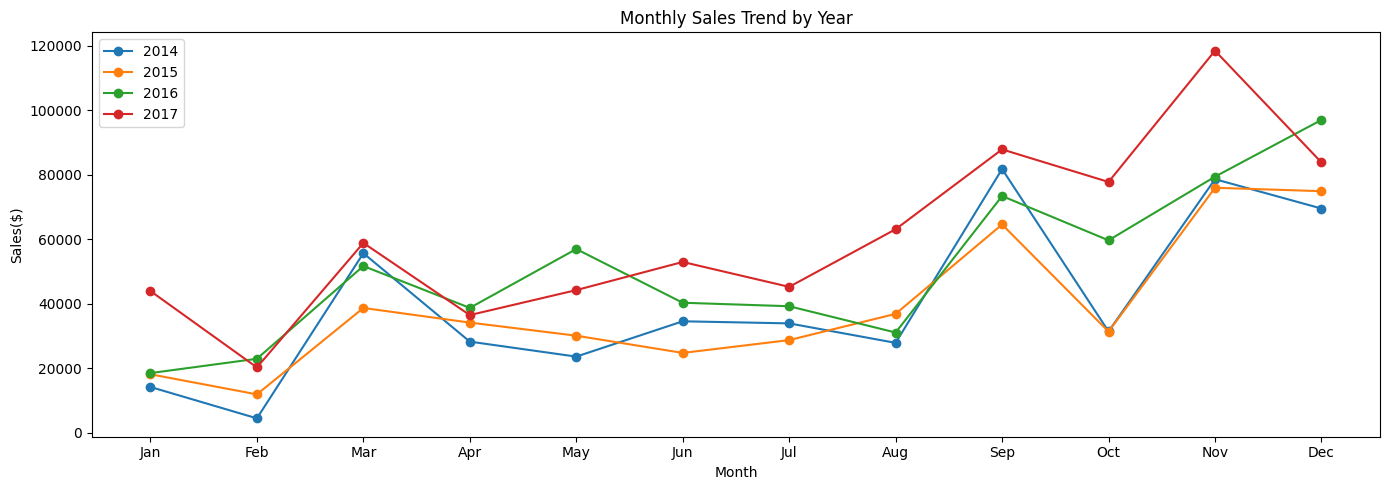

In [17]:
#KPI 2 Monthly Revenue Trend
monthly = df.groupby(["Year", "Month Name","Month"])["Sales"].sum().reset_index()
monthly = monthly.sort_values(["Year","Month"])

plt.figure(figsize=(14,5))
for year in monthly["Year"].unique():
    data = monthly[monthly["Year"] == year]
    plt.plot(data["Month Name"],data["Sales"],marker="o", label=str(year))

plt.title("Monthly Sales Trend by Year")
plt.xlabel("Month")
plt.ylabel("Sales($)")
plt.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/monthly_trend.png")
plt.show()

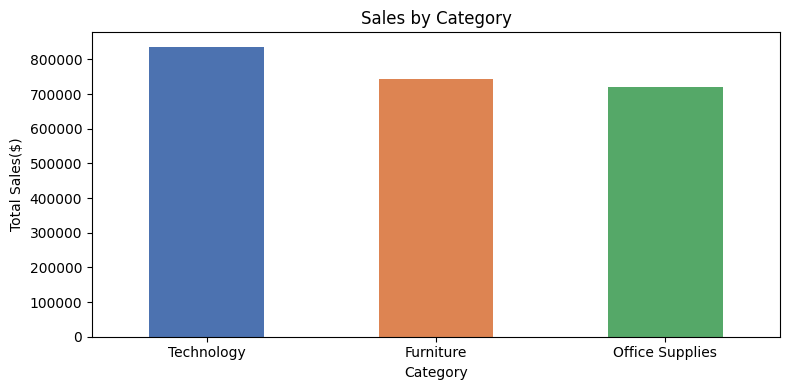

In [20]:
# Sales by category and sub category
cat_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,4))
cat_sales.plot(kind="bar",color=["#4C72B0","#DD8452","#55A868"])
plt.title("Sales by Category")
plt.ylabel("Total Sales($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("/kaggle/working/category_sales.png")
plt.show()

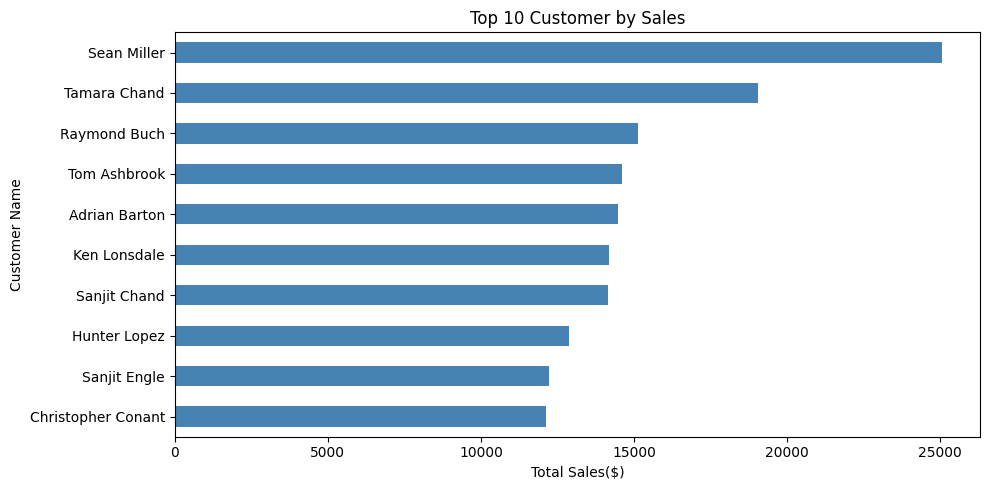

In [23]:
#KPI 4 Top 10 customer by Revenue
top_customer = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_customer.plot(kind="barh",color="steelblue")
plt.title("Top 10 Customer by Sales")
plt.xlabel("Total Sales($)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("/kaggle/working/top_customer.png")
plt.show()

In [25]:
#KPI Profit by region
region_profit = df.groupby("Region")["Sales"].sum().reset_index()
print(region_profit)

    Region        Sales
0  Central  501239.8908
1     East  678781.2400
2    South  391721.9050
3     West  725457.8245


In [26]:
#Exporting Data
df.to_csv("/kaggle/working/superstore_cleaned.csv", index=False)
monthly.to_csv("/kaggle/working/monthly_sales.csv", index=False)
region_profit.to_csv("/kaggle/working/region_profit.csv", index=False)

print("All files exported!")

All files exported!
